In [92]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

In [93]:
import matplotlib.figure as _mfig
import matplotlib.axes._base as _mpl_axes_base

# Patch missing attributes added in newer matplotlib versions.
if not hasattr(_mfig.Figure, '_remove_suplabel'):
    _mfig.Figure._remove_suplabel = lambda self, *args, **kwargs: None

if not hasattr(_mpl_axes_base, '_PropCycle'):
    class _PropCycle:
        """Stub for cross-version matplotlib pickle compatibility."""
        def __init__(self, *args, **kwargs): pass
        def __setstate__(self, state): self.__dict__.update(state)
    _mpl_axes_base._PropCycle = _PropCycle

class _CompatUnpickler(pickle.Unpickler):
    """Redirect numpy._core -> numpy.core so figures pickled with NumPy 2.x
    can be loaded in a NumPy 1.x environment."""
    def find_class(self, module, name):
        if module.startswith('numpy._core'):
            module = module.replace('numpy._core', 'numpy.core', 1)
        return super().find_class(module, name)

def _fix_figure_refs(artist, fig, visited=None):
    """Recursively set artist.figure from _parent_figure (mpl 3.11 renamed it)."""
    if visited is None:
        visited = set()
    aid = id(artist)
    if aid in visited:
        return
    visited.add(aid)
    if not hasattr(artist, 'figure'):
        artist.figure = getattr(artist, '_parent_figure', fig)
    try:
        for child in artist.get_children():
            _fix_figure_refs(child, fig, visited)
    except Exception:
        pass

def load_figure_data(pkl_path):
    """Load a pickled SpineSystematics figure and return {label: (values, edges)} for each step."""
    with open(pkl_path, 'rb') as f:
        fig = _CompatUnpickler(f).load()
    _fix_figure_refs(fig, fig)
    ax = fig.axes[0]
    data = {}
    for child in ax.get_children():
        if isinstance(child, mpatches.StepPatch):
            label = child.get_label()
            if label.startswith('_'):  # skip auto-generated labels
                continue
            d = child.get_data()  # StairData(values, edges, baseline)
            data[label] = (np.asarray(d.values, dtype=float), np.asarray(d.edges, dtype=float))
    plt.close(fig)
    return data

In [94]:
def plot_total_comparison(sig_pkl, bkg_pkl, xlabel='', title='', syst_label='', legend_loc='upper right', ax=None):
    sig_data = load_figure_data(sig_pkl)
    bkg_data = load_figure_data(bkg_pkl)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    if 'Total' in sig_data:
        vals, edges = sig_data['Total']
        ax.stairs(vals, edges, label='Signal', color='steelblue', linewidth=2.2)
    else:
        print(f"Warning: no 'Total' line found in {sig_pkl}")

    if 'Total' in bkg_data:
        vals, edges = bkg_data['Total']
        ax.stairs(vals, edges, label='Background', color='firebrick', linewidth=2.2)
    else:
        print(f"Warning: no 'Total' line found in {bkg_pkl}")

    ax.set_ylabel('Fractional uncertainty')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend(title=rf'$\bf{{{syst_label or None}}}$', fontsize=12, loc=legend_loc)
    ax.grid(True, alpha=0.3)
    ax.text(0, 1.01, r'$\bf{ICARUS}$ Work in Progress', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=10, style='italic')
    ax.text(1, 1.01, 'POT=2.5e20', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=10)
    plt.tight_layout()
    return ax

In [95]:
def plot_systematic_ratios(sig_pkl, bkg_pkl, xlabel='', title='', syst_label='', legend_loc='upper right', exclude_total=True, ax=None):
    sig_data = load_figure_data(sig_pkl)
    bkg_data = load_figure_data(bkg_pkl)

    common = sorted(set(sig_data) & set(bkg_data))
    if exclude_total:
        common = [s for s in common if s != 'Total']

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, syst in enumerate(common):
        sig_vals, edges = sig_data[syst]
        bkg_vals, _     = bkg_data[syst]
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = np.where(bkg_vals > 0, sig_vals / bkg_vals, np.nan)
        color = prop_cycle[i % len(prop_cycle)]
        ax.stairs(ratio, edges, label=syst, color=color, linewidth=1.5)

    ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.6,
               label='Signal = Background')
    ax.set_ylabel('Signal / Background fractional uncertainty')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend(title=rf'$\bf{{{syst_label or None}}}$', fontsize=10, ncol=2, loc=legend_loc)
    ax.grid(True, alpha=0.3)
    ax.text(0, 1.01, r'$\bf{ICARUS}$ Work in Progress', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=10, style='italic')
    ax.text(1, 1.01, 'POT=2.5e20', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=10)
    plt.tight_layout()
    return ax

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


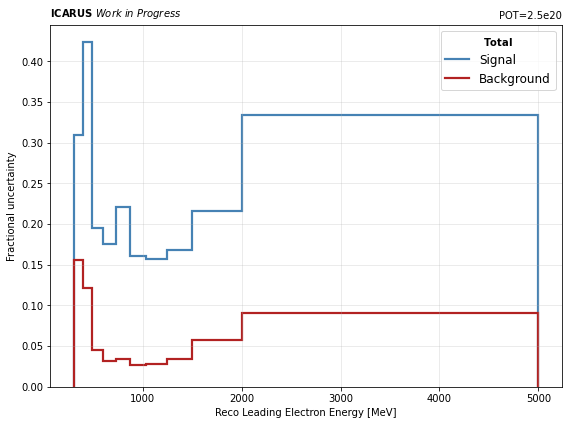

In [96]:
# --- Example usage ---
base = '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_total'

sig_pkl = f'{base}/plot_sys_eleE_signal.pkl'
bkg_pkl = f'{base}/plot_sys_eleE_background.pkl'

plot_total_comparison(sig_pkl, bkg_pkl,
                      xlabel='Reco Leading Electron Energy [MeV]',
                      title='',
                      syst_label='Total')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


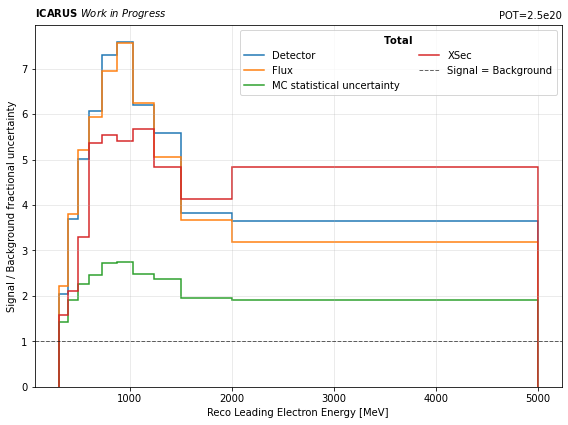

In [97]:
plot_systematic_ratios(sig_pkl, bkg_pkl,
                       xlabel='Reco Leading Electron Energy [MeV]',
                       title='',
                       syst_label='Total')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


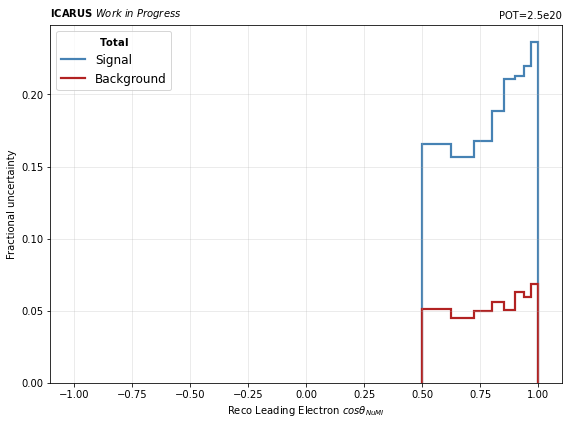

In [98]:
# --- Example usage ---
base = '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_total'

sig_pkl = f'{base}/plot_sys_eleCosThetaNUMI_signal.pkl'
bkg_pkl = f'{base}/plot_sys_eleCosThetaNUMI_background.pkl'

plot_total_comparison(sig_pkl, bkg_pkl,
                      xlabel=r'Reco Leading Electron $cos{\theta_{NuMI}}$',
                      title='',
                      syst_label='Total',
                       legend_loc='upper left')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


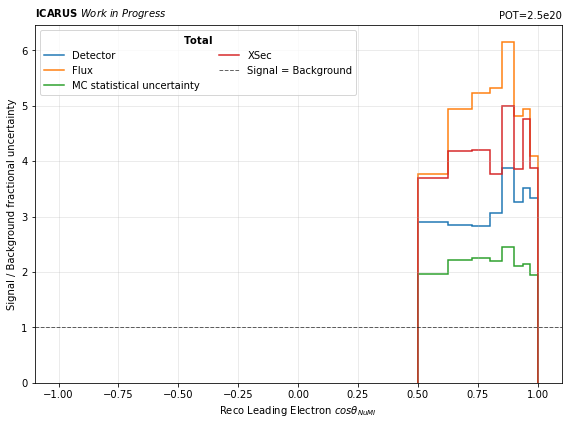

In [99]:
plot_systematic_ratios(sig_pkl, bkg_pkl,
                       xlabel=r'Reco Leading Electron $cos{\theta_{NuMI}}$',
                       title='',
                       syst_label='Total',
                       legend_loc='upper left')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


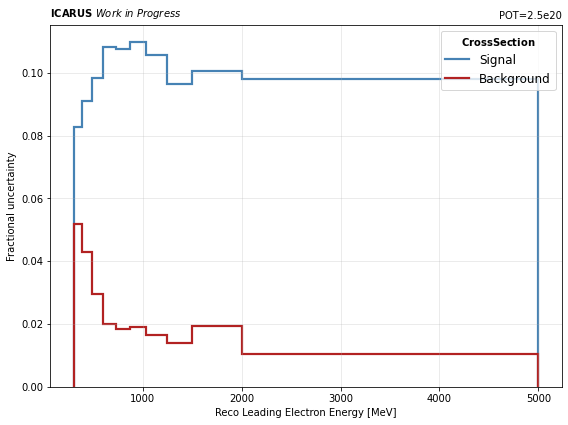

In [100]:
# --- Example usage ---
base = '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec'

sig_pkl = f'{base}/plot_sys_eleE_signal.pkl'
bkg_pkl = f'{base}/plot_sys_eleE_background.pkl'

plot_total_comparison(sig_pkl, bkg_pkl,
                      xlabel='Reco Leading Electron Energy [MeV]',
                      title='',
                      syst_label='Cross Section')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


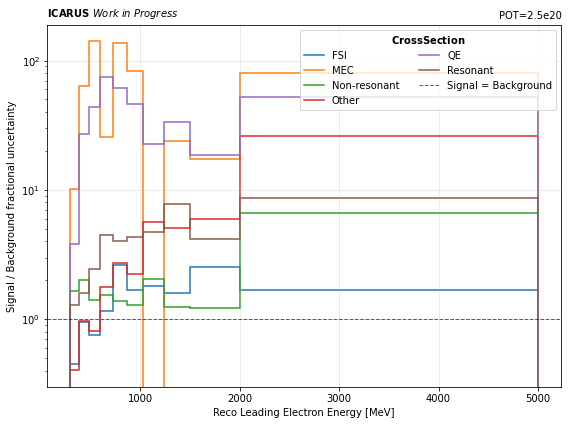

In [101]:
plot_systematic_ratios(sig_pkl, bkg_pkl,
                       xlabel='Reco Leading Electron Energy [MeV]',
                       title='',
                       syst_label='Cross Section')
plt.yscale('log')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


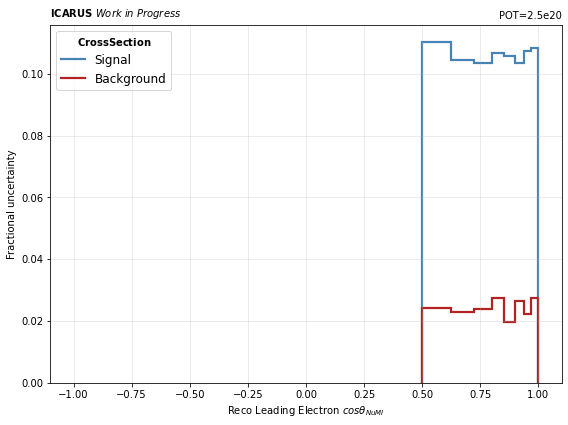

In [102]:
# --- Example usage ---
base = '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec'

sig_pkl = f'{base}/plot_sys_eleCosThetaNUMI_signal.pkl'
bkg_pkl = f'{base}/plot_sys_eleCosThetaNUMI_background.pkl'

plot_total_comparison(sig_pkl, bkg_pkl,
                      xlabel=r'Reco Leading Electron $cos{\theta_{NuMI}}$',
                      title='',
                      syst_label='Cross Section',
                       legend_loc='upper left')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


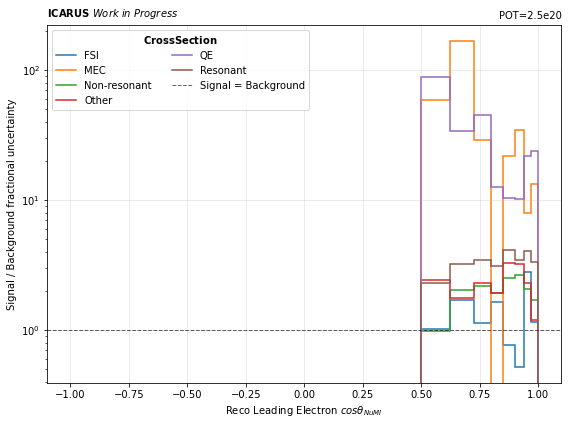

In [103]:
plot_systematic_ratios(sig_pkl, bkg_pkl,
                       xlabel=r'Reco Leading Electron $cos{\theta_{NuMI}}$',
                       title='',
                       syst_label='Cross Section',
                       legend_loc='upper left')
plt.yscale('log')
plt.show()


/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


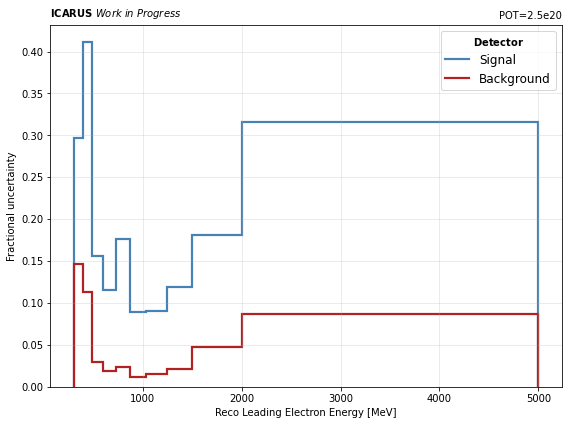

In [104]:
# --- Example usage ---
base = '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_detector'

sig_pkl = f'{base}/plot_sys_eleE_signal.pkl'
bkg_pkl = f'{base}/plot_sys_eleE_background.pkl'

plot_total_comparison(sig_pkl, bkg_pkl,
                      xlabel='Reco Leading Electron Energy [MeV]',
                      title='',
                      syst_label='Detector')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


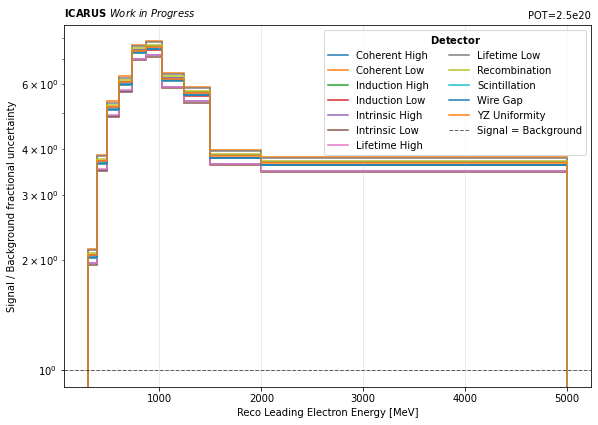

In [105]:
plot_systematic_ratios(sig_pkl, bkg_pkl,
                       xlabel='Reco Leading Electron Energy [MeV]',
                       title='',
                       syst_label='Detector')
plt.yscale('log')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


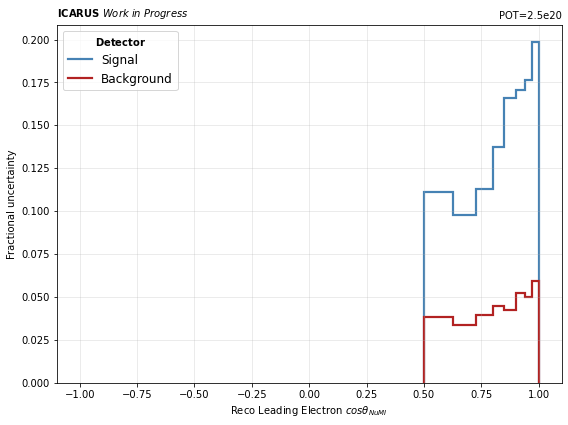

In [106]:
# --- Example usage ---
base = '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_detector'

sig_pkl = f'{base}/plot_sys_eleCosThetaNUMI_signal.pkl'
bkg_pkl = f'{base}/plot_sys_eleCosThetaNUMI_background.pkl'

plot_total_comparison(sig_pkl, bkg_pkl,
                      xlabel=r'Reco Leading Electron $cos{\theta_{NuMI}}$',
                      title='',
                      syst_label='Detector',
                       legend_loc='upper left')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


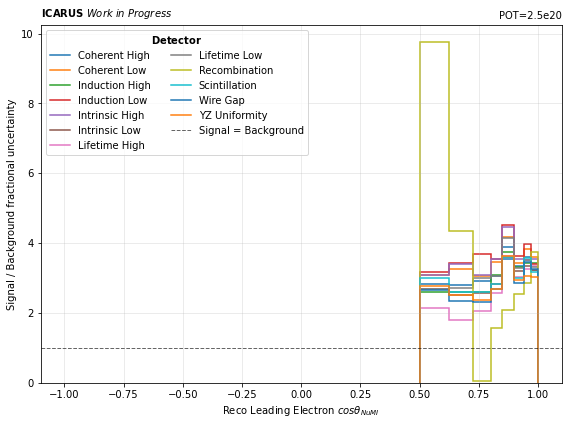

In [107]:
plot_systematic_ratios(sig_pkl, bkg_pkl,
                       xlabel=r'Reco Leading Electron $cos{\theta_{NuMI}}$',
                       title='',
                       syst_label='Detector',
                       legend_loc='upper left'
)
plt.yscale('linear')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


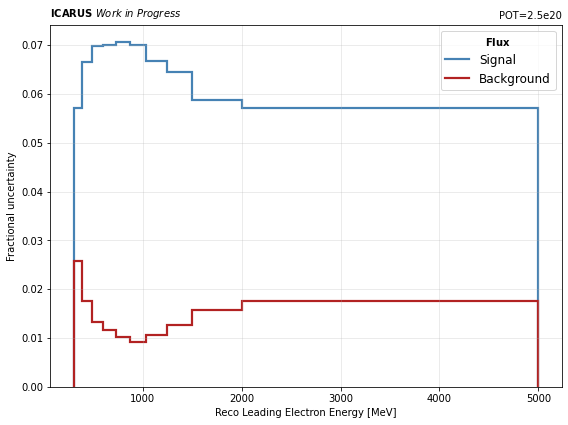

In [108]:
# --- Example usage ---
base = '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_flux'

sig_pkl = f'{base}/plot_sys_eleE_signal.pkl'
bkg_pkl = f'{base}/plot_sys_eleE_background.pkl'

plot_total_comparison(sig_pkl, bkg_pkl,
                      xlabel='Reco Leading Electron Energy [MeV]',
                      title='',
                      syst_label='Flux')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


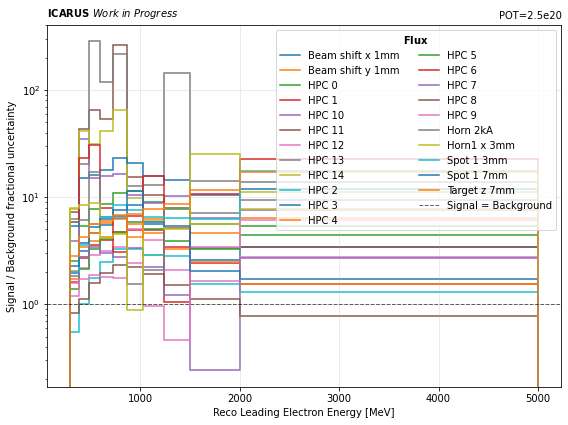

In [109]:
plot_systematic_ratios(sig_pkl, bkg_pkl,
                       xlabel='Reco Leading Electron Energy [MeV]',
                       title='',
                       syst_label='Flux')
plt.yscale('log')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


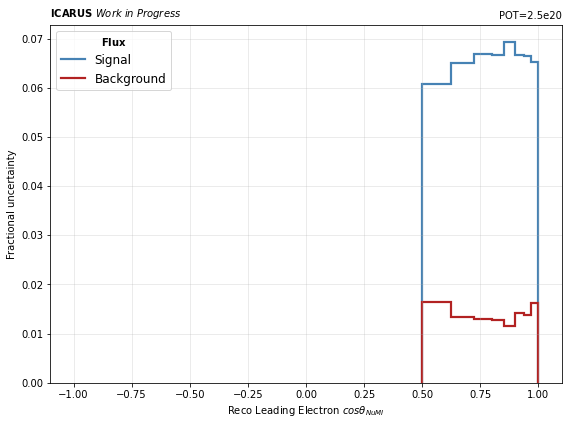

In [110]:
# --- Example usage ---
base = '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_flux'

sig_pkl = f'{base}/plot_sys_eleCosThetaNUMI_signal.pkl'
bkg_pkl = f'{base}/plot_sys_eleCosThetaNUMI_background.pkl'

plot_total_comparison(sig_pkl, bkg_pkl,
                      xlabel=r'Reco Leading Electron $cos{\theta_{NuMI}}$',
                      title='',
                      syst_label='Flux',
                      legend_loc='upper left')
plt.show()

/tmp/ipykernel_2104/3553175795.py:42: UserWarning: This figure was saved with matplotlib version 3.11.1 and loaded with 3.9.4 so may not function correctly.
  fig = _CompatUnpickler(f).load()


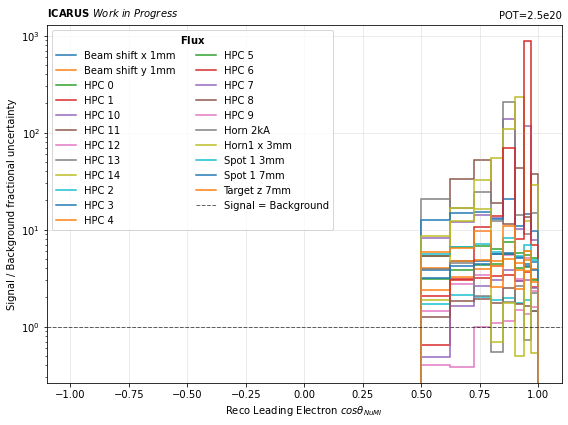

In [112]:
plot_systematic_ratios(sig_pkl, bkg_pkl,
                       xlabel=r'Reco Leading Electron $cos{\theta_{NuMI}}$',
                       title='',
                       syst_label='Flux',
                       legend_loc='upper left'
)
plt.yscale('log')
plt.show()